In [1]:
import geopandas
import libpysal
import esda
import spreg
import matplotlib

In [2]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv('baeume.csv')

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs = "EPSG:4326"
)
gdf = gdf.to_crs(epsg=3857)
gdf.head()

,latitude,longitude,uuid,gattung_botanisch,gattung_deutsch,art_botanisch,art_deutsch,alleebaum,hoehe,stammdurchmesser,stammumfang,kronendurchmesser,baumpatenschaft,geometry
0,54.057654,12.100881,d04f4edf-c22b-481d-8140-f5da1203b9c7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1347063.919 7181082.929)
1,54.053463,12.098658,9ac13cb1-d6fa-42ae-9374-0300965a97d7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1346816.406 7180288.122)
2,54.068021,12.123567,253aad1a-c704-40fb-8401-7d88f94559d2,Quercus,Eiche,Quercus robur,Stiel-Eiche,0,18.0,35.00,109.96,12.0,0,POINT (1349589.314 7183049.253)
3,54.068164,12.113794,d7a4e358-8634-4497-988e-d2e51487d1cb,Acer,Ahorn,Acer saccharum,Zucker-Ahorn,0,20.0,50.93,160.00,9.2,0,POINT (1348501.391 7183076.331)
4,54.066913,12.117171,aa50bcd3-125c-43d5-9859-9afa368c73e0,Quercus,Eiche,Quercus rubra,Amerikanische Roteiche,1,9.0,31.83,100.00,10.0,0,POINT (1348877.355 7182838.966)


In [3]:
gdf.isna().sum()
gdf.describe()

,latitude,longitude,alleebaum,hoehe,stammdurchmesser,stammumfang,kronendurchmesser,baumpatenschaft
count,70901.000000,70901.000000,70901.000000,69486.000000,69378.000000,69378.000000,69393.000000,70901.000000
mean,54.113202,12.106738,0.174469,12.407147,32.804386,103.058039,6.422328,0.002172
std,0.036345,0.044526,0.379515,8.370137,26.152694,82.161219,3.770057,0.046555
min,54.004862,12.006991,0.000000,0.400000,0.050000,0.160000,0.100000,0.000000
25%,54.082481,12.071525,0.000000,7.000000,17.000000,53.410000,4.000000,0.000000
50%,54.104562,12.096546,0.000000,11.000000,28.010000,88.000000,6.000000,0.000000
75%,54.139616,12.139764,0.000000,16.000000,43.000000,135.090000,8.100000,0.000000
max,54.252528,12.347259,1.000000,915.000000,2588.000000,8130.440000,164.000000,1.000000


In [4]:
df.rename(columns={
    "gattung_botanisch": "genus_botanical",
    "gattung_deutsch": "genus_german",
    "art_botanisch": "species_botanical",
    "art_deutsch": "species_german",
    "alleebaum": "avenue_tree",
    "hoehe": "height",
    "stammdurchmesser": "trunk_diameter",
    "stammumfang": "trunk_circumference",
    "kronendurchmesser": "crown_diameter",
    "baumpatenschaft": "tree_sponsorship"
}, inplace=True)

Renaming the columns from German to English for better understanding

In [7]:
gdf = gdf.rename(columns={"gattung_botanisch": "genus_botanical",
    "gattung_deutsch": "genus_german",
    "art_botanisch": "species_botanical",
    "art_deutsch": "species_german",
    "alleebaum": "avenue_tree",
    "hoehe": "height",
    "stammdurchmesser": "trunk_diameter",
    "stammumfang": "trunk_circumference",
    "kronendurchmesser": "crown_diameter",
    "baumpatenschaft": "tree_sponsorship" })

In [5]:
df.columns

Index(['latitude', 'longitude', 'uuid', 'genus_botanical', 'genus_german',
       'species_botanical', 'species_german', 'avenue_tree', 'height',
       'trunk_diameter', 'trunk_circumference', 'crown_diameter',
       'tree_sponsorship'],
      dtype='object')

In [8]:
gdf['height'].describe()

count    69486.000000
mean        12.407147
std          8.370137
min          0.400000
25%          7.000000
50%         11.000000
75%         16.000000
max        915.000000
Name: height, dtype: float64

Finding the NA values

In [9]:
gdf['height'].isna().sum()

np.int64(1415)

Removing unrealistic height of the trees

In [10]:
gdf = gdf[(gdf['height'] > 0) & (gdf['height'] <= 50)]

In [11]:
gdf['trunk_diameter'].describe()

count    69122.00000
mean        32.80874
std         26.13320
min          0.05000
25%         17.00000
50%         28.01000
75%         43.00000
max       2588.00000
Name: trunk_diameter, dtype: float64

In [12]:
gdf[['trunk_diameter','trunk_circumference']].describe()

,trunk_diameter,trunk_circumference
count,69122.00000,69122.000000
mean,32.80874,103.071722
std,26.13320,82.099978
min,0.05000,0.160000
25%,17.00000,53.410000
50%,28.01000,88.000000
75%,43.00000,135.090000
max,2588.00000,8130.440000


In [14]:
Q1 = gdf['trunk_diameter'].quantile(0.25)
Q3 = gdf['trunk_diameter'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

gdf = gdf[(gdf['trunk_diameter'] >= lower) &
          (gdf['trunk_diameter'] <= upper)]

In [17]:
gdf = gdf.drop_duplicates(subset='uuid')

In [18]:
gdf.isnull().sum()

latitude                0
longitude               0
uuid                    0
genus_botanical         0
genus_german            0
species_botanical       0
species_german          0
avenue_tree             0
height                  0
trunk_diameter          0
trunk_circumference     0
crown_diameter         91
tree_sponsorship        0
geometry                0
dtype: int64

In [19]:
gdf = gdf.dropna(subset=['height', 'trunk_diameter', 'crown_diameter'])

In [21]:
gdf.shape
gdf.isnull().sum()
gdf.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

here we got to know that the coordinates are projected, distances are in meters, spatial weights will work correctly

Spatial AutoCorrelation

Since this is a point dataset KNN is best

In [22]:
from libpysal.weights import KNN

w = KNN.from_dataframe(gdf, k=8)
w.transform = 'r'

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 174 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


we are initially choosing 8 because it is a standard in urban spatial analysis

In [23]:
w.n_components

174

In [24]:
w.component_labels[:20]

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1],
      dtype=int32)

In [25]:
import pandas as pd

component_sizes = pd.Series(w.component_labels).value_counts()

component_sizes.head(10)

0     34838
1     16362
36     1875
44     1335
5       838
30      734
41      633
67      605
42      426
9       407
Name: count, dtype: int64

In [26]:
component_sizes.describe()

count      174.000000
mean       384.764368
std       2909.593785
min          9.000000
25%         16.000000
50%         31.000000
75%         57.750000
max      34838.000000
Name: count, dtype: float64

Getting the Moron's I and P value for the height

In [27]:
from esda.moran import Moran

y = gdf['height']
mi = Moran(y, w)

print("Moran’s I:", mi.I)
print("p-value:", mi.p_sim)

Moran’s I: 0.6692114174720482
p-value: 0.001


Finding the Local Moron's I(LISA)

In [28]:
from esda.moran import Moran_Local

lisa = Moran_Local(y, w)

gdf['lisa_cluster'] = lisa.q
gdf['lisa_p'] = lisa.p_sim

In [29]:
gdf['significant'] = gdf['lisa_p'] < 0.05

<Axes: >

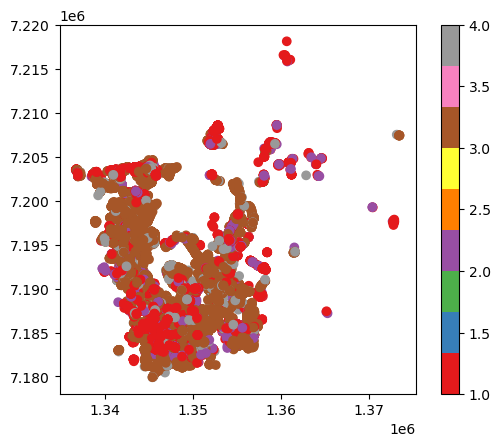

In [30]:
gdf[gdf['significant']].plot(column='lisa_cluster', cmap='Set1', legend=True)

In [31]:
sig = gdf[gdf['significant'] == True]

In [32]:
sig['lisa_cluster'].value_counts()

lisa_cluster
3    19304
1    12170
2     1653
4      729
Name: count, dtype: int64

This result says that there are 19304 low-low, 12170 high-high, 1653 low-high, 729 high-low

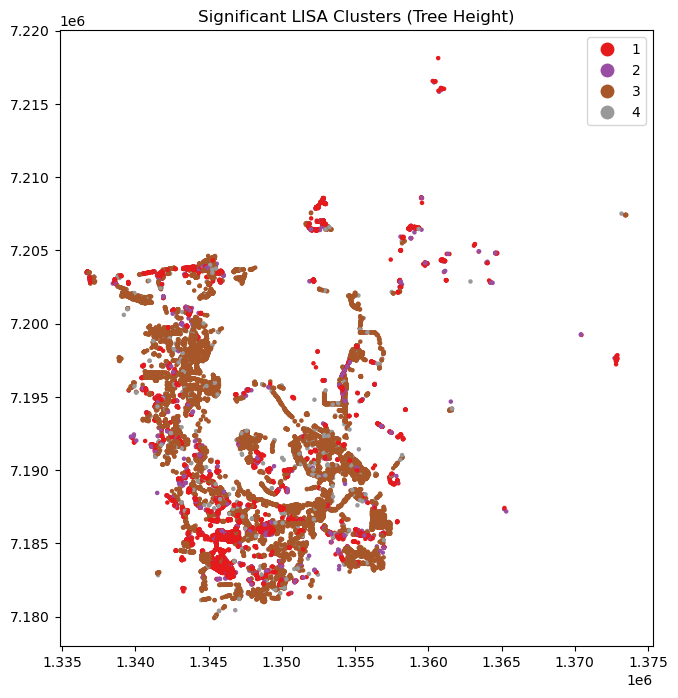

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8,8))

sig.plot(column='lisa_cluster',
         categorical=True,
         cmap='Set1',
         legend=True,
         markersize=5,
         ax=ax)

ax.set_title("Significant LISA Clusters (Tree Height)")
plt.show()

In [34]:
from spreg import OLS
import numpy as np

y = gdf['height'].values.reshape(-1,1)

X = gdf[['trunk_diameter','crown_diameter']].values

model = OLS(y, X)

print(model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     dep_var                Number of Observations:       66949
Mean dependent var  :     12.1169                Number of Variables   :           3
S.D. dependent var  :      6.5409                Degrees of Freedom    :       66946
R-squared           :      0.5530
Adjusted R-squared  :      0.5530
Sum squared residual: 1.28023e+06                F-statistic           :  41416.6748
Sigma-square        :      19.123                Prob(F-statistic)     :           0
S.E. of regression  :       4.373                Log likelihood        : -193775.246
Sigma-square ML     :      19.122                Akaike info criterion :  387556.492
S.E of regression ML:      4.3729                Schwarz criterion     :  387583.827

------------------------------------------------------------

this data indicates that trees with thicker trunks and wider crowns are taller

we got Breusch-Pagan test and Koenker-Bassett test p values as 0 this indicates Heteroskedasticity exists
Variance of errors is NOT constant

this suggests that 
Model errors vary across space
Spatial heterogeneity likely present

If this residual show spatial autocorrelation OLS is insufficient, we need spatial models

In [35]:
from esda.moran import Moran

residuals = model.u   # residuals from OLS

mi_res = Moran(residuals, w)

print("Residual Moran’s I:", mi_res.I)
print("p-value:", mi_res.p_sim)

Residual Moran’s I: 0.5640900950330908
p-value: 0.001


we got a strong autocorrelation i.e 0.56 and p significantly higher

so from this we can say that the height of the tree is not only determined by the trunk and the crown size

Spatial Regression

Spatial Lag Model

In [37]:
from spreg import ML_Lag

slm = ML_Lag(y, X, w=w, method = 'LU')

print(slm.summary)

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


MemoryError: Unable to allocate 33.4 GiB for an array with shape (66949, 66949) and data type float64

In [38]:
gdf_sample = gdf.sample(n=20000, random_state=42)

In [39]:
from libpysal.weights import KNN

w_s = KNN.from_dataframe(gdf_sample, k=8)
w_s.transform = 'r'

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 28 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [40]:
import numpy as np

y_s = gdf_sample['height'].values.reshape(-1,1)
X_s = gdf_sample[['trunk_diameter','crown_diameter']].values

In [41]:
from spreg import ML_Lag

slm = ML_Lag(y_s, X_s, w=w_s, method='LU')

print(slm.summary)

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = LU)
---------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       20000
Mean dependent var  :     12.1225                Number of Variables   :           4
S.D. dependent var  :      6.5626                Degrees of Freedom    :       19996
Pseudo R-squared    :      0.7162
Spatial Pseudo R-squared:  0.5680
Log likelihood      : -53821.8601
Sigma-square ML     :     12.2333                Akaike info criterion :  107651.720
S.E of regression   :      3.4976                Schwarz criterion     :  107683.334

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------------

here we can see a jump from 0.553 earlier with OLS to 0.716 here
this justifies spatial modelling

the most important parameter W_dep_var is 0.545 which is highly significant
this means tree height in one location is strongly influences by neighbouring tree heights

In [43]:
from spreg import ML_Error

sem = ML_Error(y_s, X_s, w=w_s, method='LU')
print(sem.summary)

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = LU)
-------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       20000
Mean dependent var  :     12.1225                Number of Variables   :           3
S.D. dependent var  :      6.5626                Degrees of Freedom    :       19997
Pseudo R-squared    :      0.5493
Log likelihood      : -53315.8809
Sigma-square ML     :     11.0904                Akaike info criterion :  106637.762
S.E of regression   :      3.3302                Schwarz criterion     :  106661.472

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         4.63141        

We can see that AIC is better for SEM
Log likelihood is also higher in SEM
Lambda is very strong in SEM when compared W_deep_var

This means clustering is not directly driven by neighbouring heights of the trees, it is also driven by spatially varying environmental factors, soil conditions, urban design, planning zones etc.

Here the Pseudo R^2 is more for SLM but for spatial models AIC and log likelihood are more reliable.
So, SEM is better

In [44]:
from sklearn.model_selection import train_test_split
import numpy as np

X_full = gdf[['trunk_diameter','crown_diameter']].values
y_full = gdf['height'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

In [45]:
from spreg import OLS

ols_train = OLS(y_train, X_train)

print(ols_train.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     dep_var                Number of Observations:       53559
Mean dependent var  :     12.1225                Number of Variables   :           3
S.D. dependent var  :      6.5424                Degrees of Freedom    :       53556
R-squared           :      0.5529
Adjusted R-squared  :      0.5529
Sum squared residual:  1.0249e+06                F-statistic           :  33117.1655
Sigma-square        :      19.137                Prob(F-statistic)     :           0
S.E. of regression  :       4.375                Log likelihood        : -155038.308
Sigma-square ML     :      19.136                Akaike info criterion :  310082.616
S.E of regression ML:      4.3745                Schwarz criterion     :  310109.282

------------------------------------------------------------

In [46]:
beta = ols_train.betas

# Add constant manually
X_test_const = np.hstack((np.ones((X_test.shape[0],1)), X_test))

y_pred = X_test_const @ beta

In [47]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Test RMSE: 4.366837922411941


In [48]:
gdf_sample = gdf.sample(n=20000, random_state=42).copy()

In [54]:
from sklearn.model_selection import train_test_split

gdf_train, gdf_test = train_test_split(
    gdf_sample, test_size=0.2, random_state=42
)

In [55]:
from libpysal.weights import KNN

w_train = KNN.from_dataframe(gdf_train, k=8)
w_train.transform = 'r'

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 16 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [56]:
import numpy as np

X_train = gdf_train[['trunk_diameter','crown_diameter']].values
y_train = gdf_train['height'].values.reshape(-1,1)

X_test = gdf_test[['trunk_diameter','crown_diameter']].values
y_test = gdf_test['height'].values.reshape(-1,1)

In [57]:
from spreg import ML_Lag

slm_train = ML_Lag(y_train, X_train, w=w_train, method='LU')

print(slm_train.summary)

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = LU)
---------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       16000
Mean dependent var  :     12.1403                Number of Variables   :           4
S.D. dependent var  :      6.6142                Degrees of Freedom    :       15996
Pseudo R-squared    :      0.7129
Spatial Pseudo R-squared:  0.5775
Log likelihood      : -43260.9958
Sigma-square ML     :     12.5725                Akaike info criterion :   86529.992
S.E of regression   :      3.5458                Schwarz criterion     :   86560.713

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------------

In [59]:
rho = slm_train.rho
beta = slm_train.betas

In [60]:
import numpy as np

X_test_const = np.hstack((np.ones((X_test.shape[0],1)), X_test))

In [62]:
print("X_test_const shape:", X_test_const.shape)
print("beta shape:", beta.shape)

X_test_const shape: (4000, 3)
beta shape: (4, 1)


In [63]:
# Remove rho from beta
beta_x = beta[:-1]   # keeps first 3 rows only

print("beta_x shape:", beta_x.shape)

# Matrix multiplication
XB = X_test_const @ beta_x

# Apply spatial multiplier
y_pred_slm = XB / (1 - rho)

beta_x shape: (3, 1)


In [64]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_slm = np.sqrt(mean_squared_error(y_test, y_pred_slm))
print("SLM Test RMSE:", rmse_slm)

SLM Test RMSE: 5.18063813047876


In [65]:
from spreg import OLS

ols_train = OLS(y_train, X_train)
beta_ols = ols_train.betas

X_test_const = np.hstack((np.ones((X_test.shape[0],1)), X_test))
y_pred_ols = X_test_const @ beta_ols

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
print("OLS Test RMSE:", rmse_ols)

OLS Test RMSE: 4.334737976133489


In [66]:
from esda.moran import Moran

# residuals from SEM (on sample model)
residuals_sem = sem.u

mi_sem = Moran(residuals_sem, w_s)

print("SEM Residual Moran’s I:", mi_sem.I)
print("p-value:", mi_sem.p_sim)

SEM Residual Moran’s I: 0.5224906785014046
p-value: 0.001


In [67]:
!pip install mgwr

In [68]:
gdf_gwr = gdf.sample(n=10000, random_state=42).copy()

In [69]:
coords = np.column_stack((gdf_gwr.geometry.x, gdf_gwr.geometry.y))

X_gwr = gdf_gwr[['trunk_diameter','crown_diameter']].values
y_gwr = gdf_gwr['height'].values.reshape(-1,1)

In [70]:
from mgwr.sel_bw import Sel_BW

selector = Sel_BW(coords, y_gwr, X_gwr)
bw = selector.search()

print("Optimal bandwidth:", bw)

Optimal bandwidth: 47.0


In [71]:
from mgwr.gwr import GWR

gwr_model = GWR(coords, y_gwr, X_gwr, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())

Model type                                                         Gaussian
Number of observations:                                               10000
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                         190230.496
Log-likelihood:                                                  -28917.642
AIC:                                                              57841.284
AICc:                                                             57843.288
BIC:                                                              98154.724
R2:                                                                   0.560
Adj. R2:                                                              0.560

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [72]:
from esda.moran import Moran
from libpysal.weights import KNN

coords = np.column_stack((gdf_gwr.geometry.x, gdf_gwr.geometry.y))
w_gwr = KNN.from_array(coords, k=8)
w_gwr.transform = 'r'

residuals_gwr = gwr_results.resid_response

mi_gwr = Moran(residuals_gwr, w_gwr)

print("GWR Residual Moran’s I:", mi_gwr.I)
print("p-value:", mi_gwr.p_sim)

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


GWR Residual Moran’s I: -0.002343117547125723
p-value: 0.317


In [73]:
X_full = gdf[['trunk_diameter','crown_diameter','avenue_tree']].values
y_full = gdf['height'].values.reshape(-1,1)

ols_full = OLS(y_full, X_full)
print(ols_full.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     dep_var                Number of Observations:       66949
Mean dependent var  :     12.1169                Number of Variables   :           4
S.D. dependent var  :      6.5409                Degrees of Freedom    :       66945
R-squared           :      0.5691
Adjusted R-squared  :      0.5691
Sum squared residual: 1.23414e+06                F-statistic           :  29475.2578
Sigma-square        :      18.435                Prob(F-statistic)     :           0
S.E. of regression  :       4.294                Log likelihood        : -192547.868
Sigma-square ML     :      18.434                Akaike info criterion :  385103.735
S.E of regression ML:      4.2935                Schwarz criterion     :  385140.182

------------------------------------------------------------

In [74]:
residuals = ols_full.u

mi_new = Moran(residuals, w)
print("New OLS Residual Moran’s I:", mi_new.I)
print("p-value:", mi_new.p_sim)

New OLS Residual Moran’s I: 0.54405877170435
p-value: 0.001


In [75]:
gdf_sample = gdf.sample(n=20000, random_state=42).copy()

X_s = gdf_sample[['trunk_diameter','crown_diameter','avenue_tree']].values
y_s = gdf_sample['height'].values.reshape(-1,1)

w_s = KNN.from_dataframe(gdf_sample, k=8)
w_s.transform = 'r'

slm = ML_Lag(y_s, X_s, w=w_s, method='LU')
print(slm.summary)

c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 28 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\DELL\anaconda3\envs\stda\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = LU)
---------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:       20000
Mean dependent var  :     12.1225                Number of Variables   :           5
S.D. dependent var  :      6.5626                Degrees of Freedom    :       19995
Pseudo R-squared    :      0.7194
Spatial Pseudo R-squared:  0.5855
Log likelihood      : -53685.1931
Sigma-square ML     :     12.0961                Akaike info criterion :  107380.386
S.E of regression   :      3.4780                Schwarz criterion     :  107419.904

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------------